In [280]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)

print("Kutuphaneler yuklendi!")

Kutuphaneler yuklendi!


In [281]:
#parse_dates=['date'] ---> string olarak değil tarih olarak okumayı sağlar 
train        = pd.read_csv('../data/train.csv', parse_dates=['date'])
test         = pd.read_csv('../data/test.csv',  parse_dates=['date'])
stores       = pd.read_csv('../data/stores.csv')
oil          = pd.read_csv('../data/oil.csv',   parse_dates=['date'])
holidays     = pd.read_csv('../data/holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv('../data/transactions.csv',    parse_dates=['date'])

print("Veriler yuklendi!")
print(f"train dataseti şekli: {train.shape}") 

Veriler yuklendi!
train dataseti şekli: (3000888, 6)


In [282]:
#Modeli eğiteceğimiz train data set, tanımak için ilk 10 satıra ön bakış 
print("TRAIN DATA SET")
print(f"Tarih aralıkları: {train['date'].min()} -- {train['date'].max()}")
print(f"Toplam Mağaza Sayısı: {train['store_nbr'].nunique}") # eşsiz birbirinden farklı mağazalar için toplamı -> .nunique
print(f"Urun Kategorisi: {train['family'].nunique}")
print(f"Toplam Satır: {len(train):,}")
train.head(10)

TRAIN DATA SET
Tarih aralıkları: 2013-01-01 00:00:00 -- 2017-08-15 00:00:00
Toplam Mağaza Sayısı: <bound method IndexOpsMixin.nunique of 0          1
1          1
2          1
3          1
4          1
          ..
3000883    9
3000884    9
3000885    9
3000886    9
3000887    9
Name: store_nbr, Length: 3000888, dtype: int64>
Urun Kategorisi: <bound method IndexOpsMixin.nunique of 0                          AUTOMOTIVE
1                           BABY CARE
2                              BEAUTY
3                           BEVERAGES
4                               BOOKS
                      ...            
3000883                       POULTRY
3000884                PREPARED FOODS
3000885                       PRODUCE
3000886    SCHOOL AND OFFICE SUPPLIES
3000887                       SEAFOOD
Name: family, Length: 3000888, dtype: str>
Toplam Satır: 3,000,888


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0
6,6,2013-01-01,1,CELEBRATION,0.0,0
7,7,2013-01-01,1,CLEANING,0.0,0
8,8,2013-01-01,1,DAIRY,0.0,0
9,9,2013-01-01,1,DELI,0.0,0


In [283]:
# Veri Kalitesi Kontrolü (eksik değer var mı nerede var?)
# Her dosyadaki eksik değerleri tablo halinde göster.
dosyalar = {
    'train'       : train,
    'test'        : test,
    'stores'      : stores,
    'oil'         : oil,
    'holidays'    : holidays,
    'transactions': transactions
}

for isim, df in dosyalar.items():
    eksik = df.isnull().sum()          # Her sütundaki eksik değer sayısı
    eksik = eksik[eksik > 0]           # Sadece eksik olanları filtrele
    if len(eksik) > 0:
        print(f"{isim}: eksik değer var!!")
    else:
        print(f" {isim}: eksik değer yok")

print("Oil eksik çıktı acil reaksiyon almaya gerek yok çünkü borsanın kapalı olduğu günler vs. fakat sales veya stores eksik hatalı olsaydı direkt düzeltme gerekirdi!! ")

 train: eksik değer yok
 test: eksik değer yok
 stores: eksik değer yok
oil: eksik değer var!!
 holidays: eksik değer yok
 transactions: eksik değer yok
Oil eksik çıktı acil reaksiyon almaya gerek yok çünkü borsanın kapalı olduğu günler vs. fakat sales veya stores eksik hatalı olsaydı direkt düzeltme gerekirdi!! 


count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64
Sıfır Satış Olan Gün sayısı Oranı: %31.3


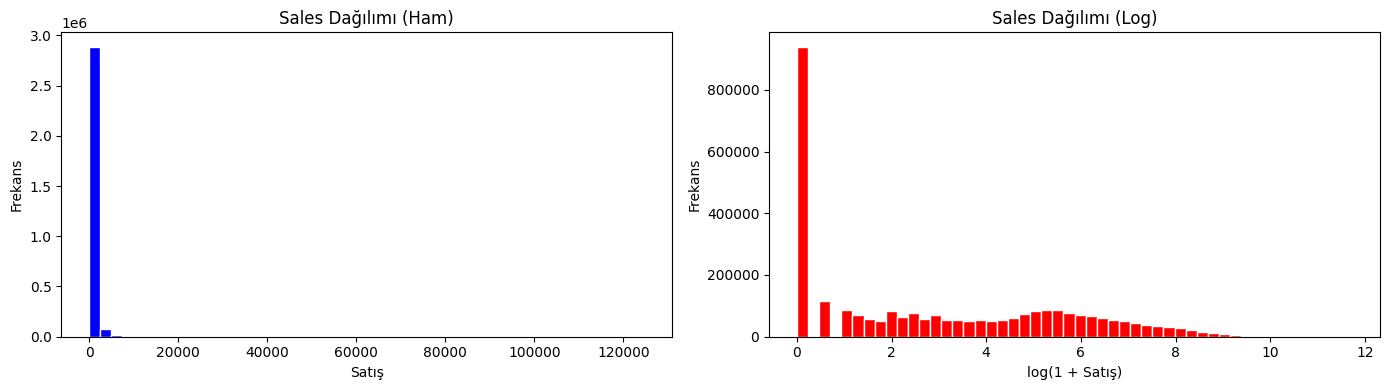

In [284]:
#Hedef Değişken Analizi -sales- (Bu değişkeni derinlemesine tanımalıyız)
#Tahmin etmeye çalıştığımız şey: sales (birim satış)
print(train['sales'].describe()) # sales sütunu istatistikleri
print(f"Sıfır Satış Olan Gün sayısı Oranı: %{(train['sales'] == 0).mean() * 100:.1f}") #Sıfır satış olan gün çok yaygın !!

#Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

#Sol Grafik --> Ham Dağılım 
axes[0].hist(train['sales'], bins=50, color='blue', edgecolor='white')
axes[0].set_title('Sales Dağılımı (Ham)')
axes[0].set_xlabel('Satış')
axes[0].set_ylabel('Frekans')

# Sales çok dağınık bu yüzden log ile dağılımın yoğun olduğu yere odaklanılır
#Sağ Grafik --> Log Dağılım 
axes[1].hist(np.log1p(train['sales']), bins=50, color='red', edgecolor='white')
axes[1].set_title('Sales Dağılımı (Log)')
axes[1].set_xlabel('log(1 + Satış)')
axes[1].set_ylabel('Frekans')

plt.tight_layout()
plt.show()

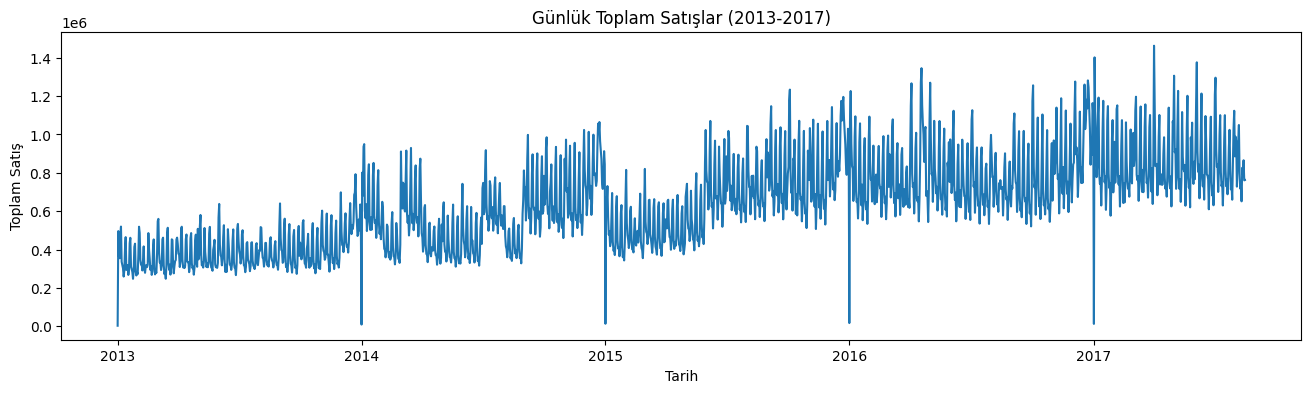

-> Genel Yukarı Trend: Zincir büyüyor olabilitesi fazla
-> Belirli dönemlerde ani düşüşler: Tatil, deprem vb
-> Yılsonu (aralık ayı) artış: Noel etkisi


In [285]:
# Zaman trendi analizi - trend ve mevsimsellik etkisi-
# zaman serisi tahmini sayesinde --> Geçmişte ne olmuş? gelecek de buna benzer davranır

#Günlük toplam satışı hesapla
gunluk_satis = train.groupby('date')['sales'].sum().reset_index() #goupby('date')->her tarihi grupla, ['Sales'].sum()-> o günün toplam satışını al

#Görselleştir
plt.figure(figsize=(16, 4))
plt.plot(gunluk_satis['date'], gunluk_satis['sales'] )
plt.title('Günlük Toplam Satışlar (2013-2017)')
plt.xlabel('Tarih')
plt.ylabel('Toplam Satış')
plt.show()

print("-> Genel Yukarı Trend: Zincir büyüyor olabilitesi fazla")
print("-> Belirli dönemlerde ani düşüşler: Tatil, deprem vb")
print("-> Yılsonu (aralık ayı) artış: Noel etkisi")


In [286]:
#Mağaza analizi ilk bakış
print('Mağaza tipleri:\n',stores['type'].value_counts())
print('Mağaza şehir dağılımları:\n',stores['city'].value_counts().head(10))
print('Tüm mağaza bilgileri:\n',stores.head(10))

Mağaza tipleri:
 type
D    18
C    15
A     9
B     8
E     4
Name: count, dtype: int64
Mağaza şehir dağılımları:
 city
Quito            18
Guayaquil         8
Santo Domingo     3
Cuenca            3
Latacunga         2
Ambato            2
Machala           2
Manta             2
Cayambe           1
Riobamba          1
Name: count, dtype: int64
Tüm mağaza bilgileri:
    store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4
5          6          Quito                       Pichincha    D       13
6          7          Quito                       Pichincha    D        8
7          8          Quito            

In [287]:
#Train datasetinde sadece store_nbr var, tip/şehir bilgisi yok
#stores'u traine'e merge ederek bilgileri ekliyoruz

traine_merge = train.merge(stores , on='store_nbr',how='left')

#tip bazı ortalama satış(toplam değil çünkü A=9, E=4 mağaza var adil olmaz)
tip_satis = traine_merge.groupby('type')['sales'].mean().sort_values(ascending=False) #(ascending=False büyükten küçüğe sıralar,() bırakılırsa küçükten büyüğe sıralar)
print('tip bazında ortalama satış:\n' ,tip_satis)

tip bazında ortalama satış:
 type
A    705.878743
D    350.979407
B    326.739714
E    269.121301
C    197.263301
Name: sales, dtype: float64


Text(0.5, 0, 'cluster')

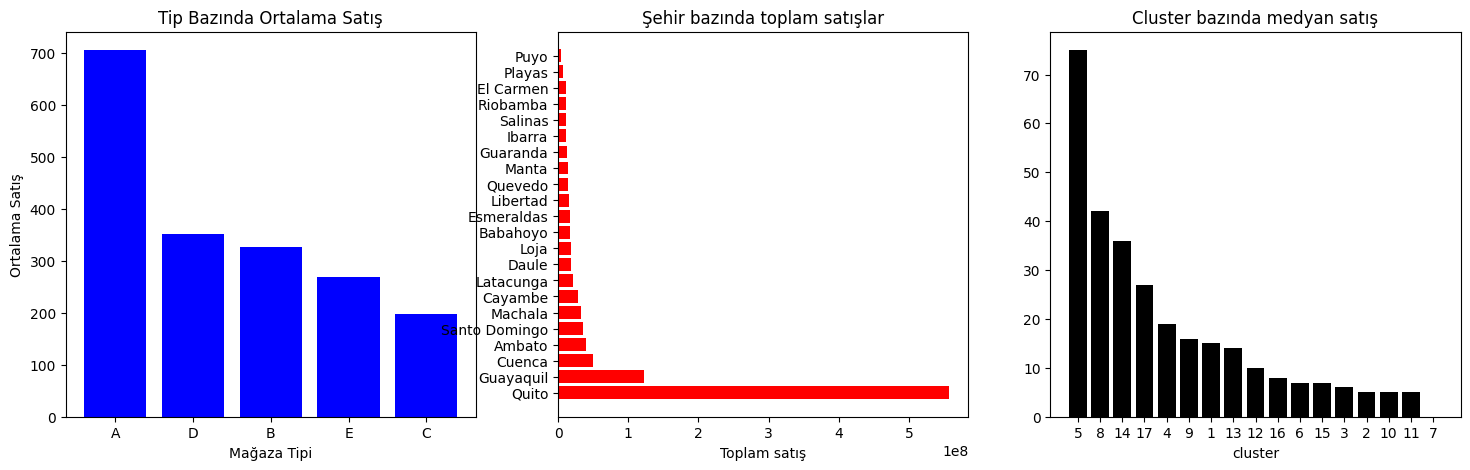

In [288]:
#Mağaza analizi görselleştirme (3 grafik yanyana)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#1-Tip bazında satış karşılaştırması (kategori karşılaştırması -> BarChart)
tip_satis = traine_merge.groupby('type')['sales'].mean().sort_values(ascending=False) #(ascending=False büyükten küçüğe sıralar,() bırakılırsa küçükten büyüğe sıralar)
axes[0].bar(tip_satis.index,tip_satis.values,color='blue')
axes[0].set_title('Tip Bazında Ortalama Satış')
axes[0].set_xlabel('Mağaza Tipi')
axes[0].set_ylabel('Ortalama Satış')

#2-Şehir bazında toplam satış
sehir_satis = traine_merge.groupby('city')['sales'].sum().sort_values(ascending=False)
axes[1].barh(sehir_satis.index,sehir_satis.values,color='red')
axes[1].set_title('Şehir bazında toplam satışlar')
axes[1].set_xlabel('Toplam satış')

#3-Cluster bazında ortalama satış 
cluster_satis = traine_merge.groupby('cluster')['sales'].median().sort_values(ascending=False)
axes[2].bar(cluster_satis.index.astype(str),cluster_satis.values,color='black')
axes[2].set_title('Cluster bazında medyan satış')
axes[2].set_xlabel('cluster')





Kaç adet kategori var:
 33


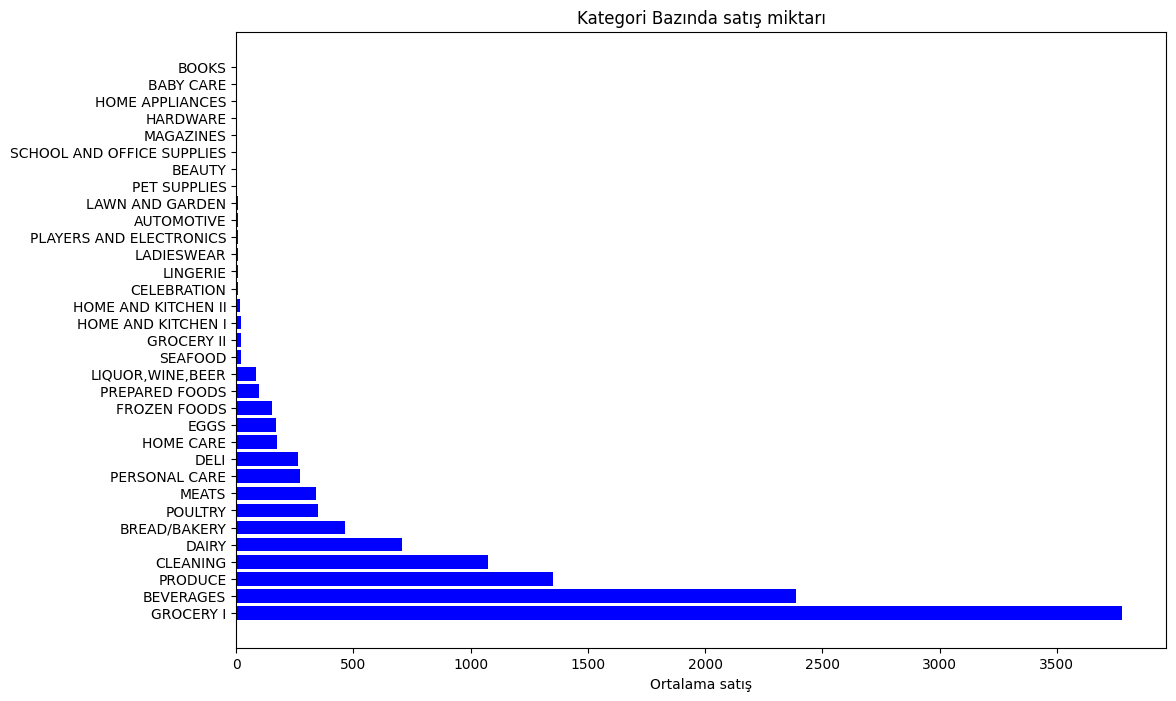

promosyon_var
False    2389559
True      611329
Name: count, dtype: int64
Promosyon etkisi: 
promosyon_var
False     158.246681
True     1137.693730
Name: sales, dtype: float64


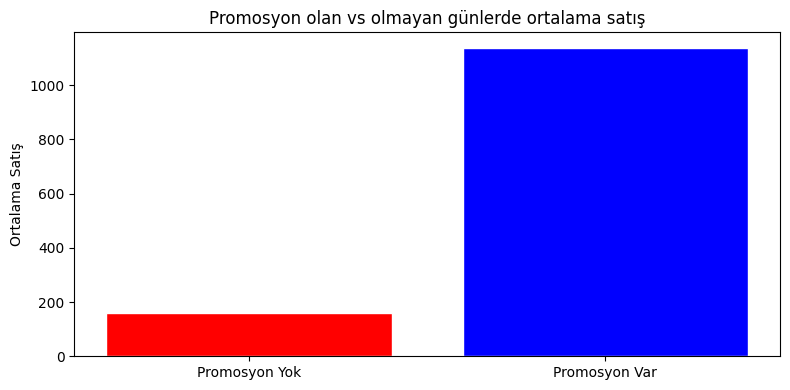

family
SCHOOL AND OFFICE SUPPLIES    4257.0
BABY CARE                     1414.6
PET SUPPLIES                   351.5
HOME AND KITCHEN II            300.6
PRODUCE                        207.8
HOME APPLIANCES                205.7
LAWN AND GARDEN                204.6
HOME CARE                      203.5
PLAYERS AND ELECTRONICS        185.5
BEAUTY                         169.3
Name: etki_yuzdesi, dtype: float64


In [289]:
#Ürün Kategorisi Analizi

print('Kaç adet kategori var:\n', train['family'].nunique())

#Hangi kategori ortalama ne kadar satıyor?
kategori_satis = train.groupby('family')['sales'].mean().sort_values(ascending=False)
plt.figure(figsize=(12,8))
plt.barh(kategori_satis.index,kategori_satis.values,color='blue')
plt.title('Kategori Bazında satış miktarı')
plt.xlabel('Ortalama satış')
plt.show()

#Promosyon etkisi (promosyon satışı artırıyor mu?)
train['promosyon_var'] = train['onpromotion']>0
print(train['promosyon_var'].value_counts())
promosyon_etkisi = train.groupby('promosyon_var')['sales'].mean()
print("Promosyon etkisi: ")
print(promosyon_etkisi.head(10)) 

plt.figure(figsize=(8,4))
plt.bar(['Promosyon Yok','Promosyon Var'],
        promosyon_etkisi.values,
        color =['red','blue'],
        edgecolor='white')
plt.title('Promosyon olan vs olmayan günlerde ortalama satış')
plt.ylabel('Ortalama Satış')
plt.tight_layout()
plt.show()

#Hangi kategoride promosyon daha etkili?

promosyon_kategori = train.groupby(['family','promosyon_var'])['sales'].mean().unstack()
promosyon_kategori['etki_yuzdesi'] = ((promosyon_kategori[True] - promosyon_kategori[False]) / promosyon_kategori[False] * 100).round(1)
print(promosyon_kategori['etki_yuzdesi'].sort_values(ascending=False).head(10))



Oil Verisi: 
 (1218, 2)
         date  dcoilwtico
0  2013-01-01         NaN
1  2013-01-02       93.14
2  2013-01-03       92.97
3  2013-01-04       93.12
4  2013-01-07       93.20
5  2013-01-08       93.21
6  2013-01-09       93.08
7  2013-01-10       93.81
8  2013-01-11       93.60
9  2013-01-14       94.27
10 2013-01-15       93.26
11 2013-01-16       94.28
12 2013-01-17       95.49
13 2013-01-18       95.61
14 2013-01-21         NaN
15 2013-01-22       96.09
16 2013-01-23       95.06
17 2013-01-24       95.35
18 2013-01-25       95.15
19 2013-01-28       95.95
Doldurma öncesi analiz için Eksik değer: 43 adet
Doldurma sonrası eksik değer sayısı :0


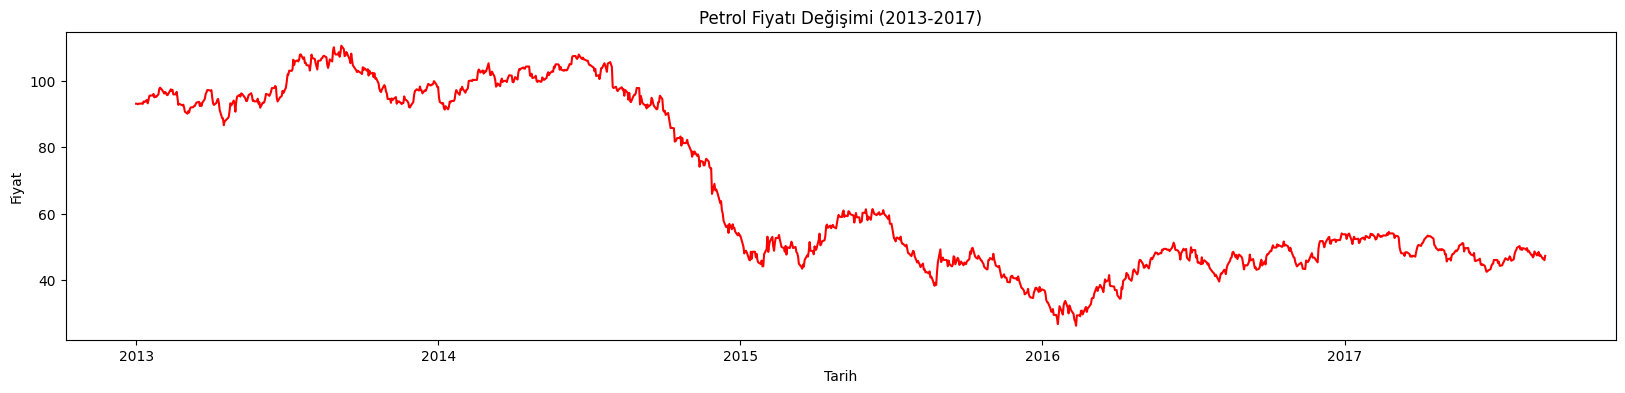

In [290]:
#TASK-8: Petrol fiyat etkisi
print('Oil Verisi: \n', oil.shape )
print(oil.head(20))
print(f"Doldurma öncesi analiz için Eksik değer: {oil['dcoilwtico'].isnull().sum()} adet")

#eksik verileri doldur(borsa tatilleri ffill ile önceki günün değerini ata)
oil['dcoilwtico'] = oil['dcoilwtico'].ffill().bfill()  #.bfill ile sonraki günün değerini ata eğer önceki günde veri yoksa
print(f"Doldurma sonrası eksik değer sayısı :{oil['dcoilwtico'].isnull().sum()}")

#Fiyatın zamanla değişimi (LineChart)
plt.figure(figsize=(20,4))
plt.plot(oil['date'],oil['dcoilwtico'], color='red')
plt.title('Petrol Fiyatı Değişimi (2013-2017)')
plt.xlabel('Tarih')
plt.ylabel('Fiyat')
plt.show()


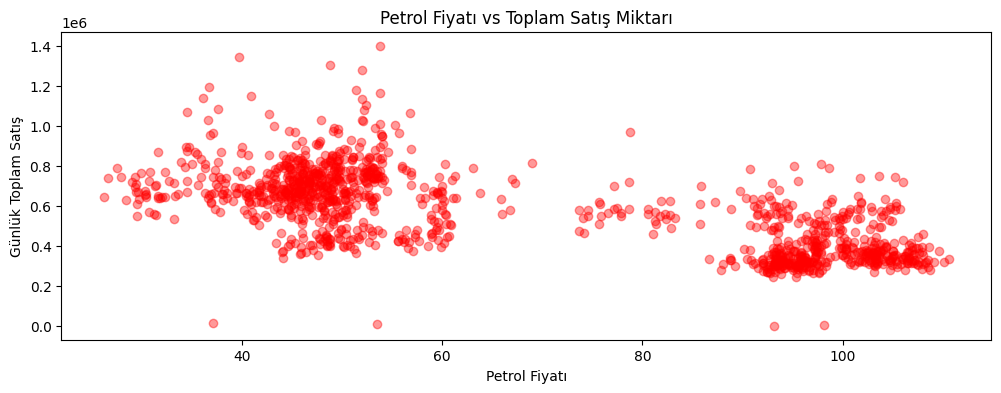

Petrol-Satış korelasyonu: -0.690
 R < 0 negatif ilişki, -1'e yakın çıktığından tam negatife yakın demektir


In [291]:
#Petrol fiyatına göre günlük satış miktarı

gunluk_satis = train.groupby('date')['sales'].sum().reset_index()
petrol_satis = gunluk_satis.merge(oil, on='date', how='left') #oil verilerini günlük satış ile birleştir(her tarihe karşılık petrol fiyatı)

#ScatterPlot ile karşılaştırma (2 sayısal değer)
# x:petrol fiyatı, y=toplam satış 

plt.figure(figsize=(12,4))
plt.scatter(petrol_satis['dcoilwtico'],
            petrol_satis['sales'],
            alpha=0.4,
            color='red')
            
plt.title('Petrol Fiyatı vs Toplam Satış Miktarı')
plt.xlabel('Petrol Fiyatı')
plt.ylabel('Günlük Toplam Satış')
plt.show()

korelasyon = petrol_satis['dcoilwtico'].corr(petrol_satis['sales'])
print(f"Petrol-Satış korelasyonu: {korelasyon:.3f}")
print(" R < 0 negatif ilişki, -1'e yakın çıktığından tam negatife yakın demektir")



In [292]:
#Task-9: Tatil-Satış Analizi

#genel bakış
print(f"Holidays verisi:\n", holidays.shape )
print(holidays.head(10))
print("\n Tatil tipleri:")
print(holidays['type'].value_counts() )
print("\n Tatil kapsamı (national,rational,local)")
print(holidays['locale'].value_counts())

Holidays verisi:
 (350, 6)
        date     type    locale locale_name                    description  \
0 2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1 2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2 2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3 2012-04-14  Holiday     Local    Libertad      Cantonizacion de Libertad   
4 2012-04-21  Holiday     Local    Riobamba      Cantonizacion de Riobamba   
5 2012-05-12  Holiday     Local        Puyo         Cantonizacion del Puyo   
6 2012-06-23  Holiday     Local    Guaranda      Cantonizacion de Guaranda   
7 2012-06-25  Holiday  Regional    Imbabura  Provincializacion de Imbabura   
8 2012-06-25  Holiday     Local   Latacunga     Cantonizacion de Latacunga   
9 2012-06-25  Holiday     Local     Machala           Fundacion de Machala   

   transferred  
0        False  
1        False  
2        False  
3        False  
4        False  
5        Fal

Tatil Tipine Göre Ortalama Satış:
type
Additional    487.628925
Transfer      467.753110
Bridge        446.750854
Event         425.660065
Work Day      372.157524
Holiday       358.433812
Normal Gun    352.159181
Name: sales, dtype: float64


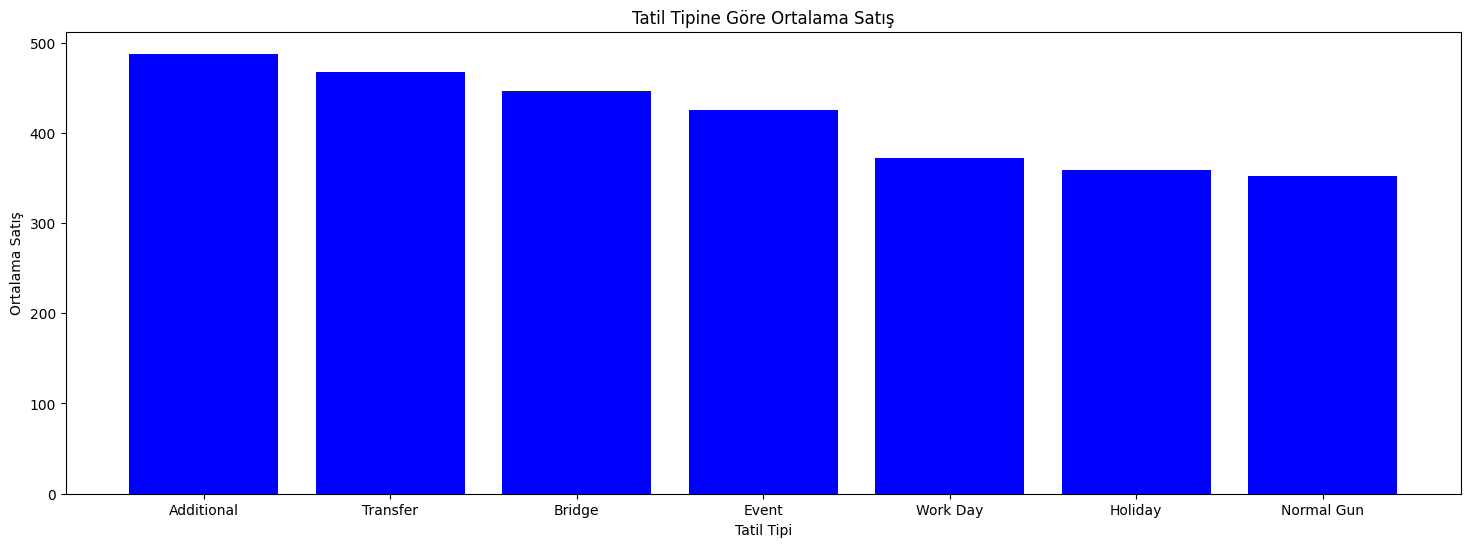

In [293]:
#Tatil günlerinde satış analizi

tatil_gunleri = holidays[['date','type','locale']] #tarihler tatil mi değil mi?
train_tatil = train.merge(tatil_gunleri, on='date' , how='left') #how='left' tatil olmayanlar NaN

train_tatil['type'] = train_tatil['type'].fillna('Normal Gun')
train_tatil['locale'] = train_tatil['locale'].fillna('Normal')

tatil_satis = train_tatil.groupby('type')['sales'].mean().sort_values(ascending=False)
print("Tatil Tipine Göre Ortalama Satış:")
print(tatil_satis)

#Tatil tipine göre satış görselleştirmesi barchart
plt.figure(figsize=(18,6))
plt.bar(tatil_satis.index,tatil_satis.values,color='blue')
plt.title('Tatil Tipine Göre Ortalama Satış')
plt.xlabel('Tatil Tipi')
plt.ylabel('Ortalama Satış')
plt.show()

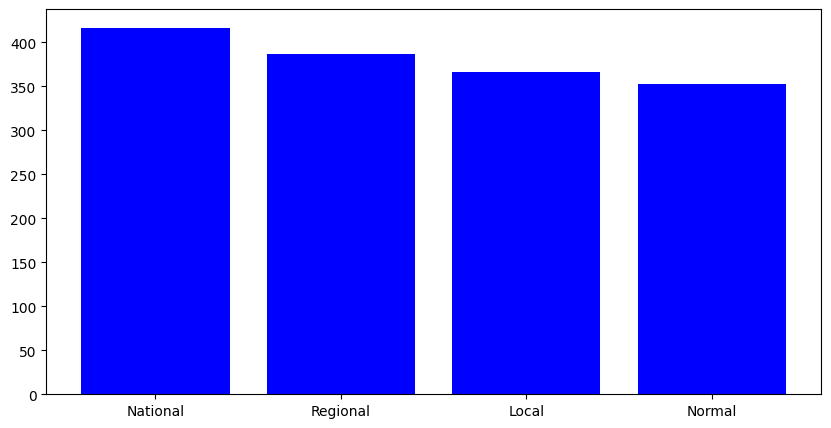

In [294]:
#Local tipine göre Satış analizi(Regional, Local, National)
lokasyon_satis = train_tatil.groupby('locale')['sales'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
plt.bar(lokasyon_satis.index,lokasyon_satis.values,color='blue')
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.show()

In [295]:
#Task-10: EDA Sonu -> datasetleri birleştirme (train tek bir tablo ister)(merge ile)

#Mağaza bilgisi ekle
df = train.merge(stores, on='store_nbr', how='left')
print(f"Stores eklendi: {df.shape}")
#Petrol fiyatı ekle
df = train.merge(oil, on='date' , how='left')
print(f"Petrol fiyatı eklendi: {df.shape}")
#İşlem sayısını ekle
df = df.merge(transactions, on=['date','store_nbr'], how='left') #date + store_nbr ortak sütunlar -> mağaza günlük işlem sayısı
print(f"Transactions eklendi: {df.shape}")
#Tatil bilgisi
ulusal_tatiller = holidays[holidays['locale'] == 'National'][['date', 'type']] # sadece nationallara bakalım local/region şehire göre değişir
ulusal_tatiller = ulusal_tatiller.rename(columns={'type': 'tatil_tipi'})#type sütununu yeniden adlandır
ulusal_tatiller = ulusal_tatiller.drop_duplicates(subset='date')#merge'de aynı satır 2 veri ile eşleşirse patlamasın
df = df.merge(ulusal_tatiller, on=['date'], how='left')
print(f"Holidays eklendi: {df.shape}")

print("\nBirleştirilmiş Veri:")
print(df.head(10))


Stores eklendi: (3000888, 11)
Petrol fiyatı eklendi: (3000888, 8)
Transactions eklendi: (3000888, 9)
Holidays eklendi: (3000888, 10)

Birleştirilmiş Veri:
   id       date  store_nbr        family  sales  onpromotion  promosyon_var  \
0   0 2013-01-01          1    AUTOMOTIVE    0.0            0          False   
1   1 2013-01-01          1     BABY CARE    0.0            0          False   
2   2 2013-01-01          1        BEAUTY    0.0            0          False   
3   3 2013-01-01          1     BEVERAGES    0.0            0          False   
4   4 2013-01-01          1         BOOKS    0.0            0          False   
5   5 2013-01-01          1  BREAD/BAKERY    0.0            0          False   
6   6 2013-01-01          1   CELEBRATION    0.0            0          False   
7   7 2013-01-01          1      CLEANING    0.0            0          False   
8   8 2013-01-01          1         DAIRY    0.0            0          False   
9   9 2013-01-01          1          DELI    

In [296]:
#Birleştirilmiş verilerde NaN kontrolü-düzeltilmesi
eksik = df.isnull().sum()
eksik = eksik[eksik>0]
print(eksik)
print("\ndcoilwtico -> ffill,bfill ile doldur(borsa haftasonu ve tatilde kapalı)")
print("\ntransactions -> bazı mağazalar o gün satış yapmamış 0 ile doldur")
print("\ntatil_tipi -> çoğu gün tatil değil Normal ile doldur \n")

df['dcoilwtico'] = df['dcoilwtico'].ffill().bfill()
df['transactions'] = df['transactions'].fillna(0)
df['tatil_tipi'] = df['tatil_tipi'].fillna('Normal')

eksik = df.isnull().sum()
eksik = eksik[eksik>0]
print(f"Eksik değer kaldı mı kontrol: {eksik}")

dcoilwtico       857142
transactions     245784
tatil_tipi      2746062
dtype: int64

dcoilwtico -> ffill,bfill ile doldur(borsa haftasonu ve tatilde kapalı)

transactions -> bazı mağazalar o gün satış yapmamış 0 ile doldur

tatil_tipi -> çoğu gün tatil değil Normal ile doldur 

Eksik değer kaldı mı kontrol: Series([], dtype: int64)
